<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/Progetto_Deep_Learnig_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Ottimizzazione delle Prestazioni di una Rete Neurale per il Settore Food
**Cliente:** GourmetAI Inc.  
**Ambito:** Computer Vision / Deep Learning per la Tecnologia Alimentare  

---

##  Introduzione e Contestualizzazione
**GourmetAI Inc.**, rinomata azienda nel settore della tecnologia alimentare, si trova ad affrontare sfide crescenti nel migliorare l'accuratezza e l'efficienza dei propri sistemi di classificazione delle immagini di cibo.

La necessità di fornire ai clienti soluzioni avanzate e di alta qualità per identificare e categorizzare correttamente le pietanze è essenziale per migliorare l'esperienza utente e ottimizzare i processi aziendali.

---

##  Benefici del Progetto
L'implementazione di tecniche avanzate di *Deep Learning* per la classificazione delle immagini offre vantaggi strategici tangibili:

1. **Miglioramento dell'Esperienza Utente:**  
   Un sistema preciso e affidabile migliora significativamente l'interazione degli utenti con le applicazioni di riconoscimento visivo, fornendo risultati rapidi e accurati.
2. **Ottimizzazione dei Processi Aziendali:**  
   Automatizzare la classificazione riduce il tempo e le risorse necessarie per identificare e categorizzare i cibi, aumentando l'efficienza operativa complessiva.
3. **Innovazione Tecnologica e Leadership di Mercato:**  
   L'adozione di architetture all'avanguardia consolida la posizione di GourmetAI Inc. come leader nell'innovazione tecnologica applicata al settore *Food*.

---

##  Dettagli del Progetto
Il progetto prevede lo sviluppo di un modello avanzato di classificazione visiva basato sul dataset **Food Classification**, potenziato da tecniche di *Data Augmentation* per incrementare la diversità e la qualità delle immagini di input.

### Obiettivi Principali
* **Strategie di Augmentation:** Implementare tecniche avanzate per arricchire il dataset e prevenire il *overfitting*.
* **Divisione del Dataset:** Suddividere i dati in `trainset`, `valset` e `testset` per garantire una valutazione rigorosa.
* **Transfer Learning:** Selezionare architetture pre-addestrate (es. *MobileNetV3*, *EfficientNet*) per velocizzare la convergenza e massimizzare le prestazioni.
* **Fine-Tuning e Hyperparameters:** Progettare un classificatore personalizzato ed eseguire l'ottimizzazione degli iperparametri (learning rate, batch size, weight decay).
* **Validazione e Regolarizzazione:** Applicare tecniche di monitoraggio (*Validation Loss/Accuracy*) e regolarizzazione per affinare la capacità di generalizzazione.
* **Test Finale:** Valutare le prestazioni sul test set per confermare il raggiungimento dei target aziendali.

---

##  Fasi Operative del Progetto
1. **Sviluppo delle Strategie di Augmentation:** Esplorazione e applicazione di trasformazioni visive sui dati.
2. **Preparazione del Dataset:** Partizionamento del dataset e creazione di data loader efficienti.
3. **Selezione dell'Architettura:** Scelta e integrazione di reti backbone con pesi pre-addestrati (*ImageNet*).
4. **Fine-Tuning & Setup Iperparametri:** Progettazione del *head* di classificazione e configurazione degli ottimizzatori.
5. **Validazione & Regolarizzazione:** Cicli iterativi di training/validation con prevenzione del degrado delle prestazioni.
6. **Test Finale & Benchmarking:** Misurazione delle metriche finali di accuratezza e capacità di generalizzazione.

---

##  Motivazione Strategica
Per GourmetAI Inc., la precisione nella classificazione delle immagini di cibo è un **requisito fondamentale**. Aumentare l'efficacia del sistema non solo soddisfa le esigenze pratiche dei clienti e della gestione aziendale, ma crea un vantaggio competitivo durevole e all'avanguardia sul mercato globale.

## importiamo le librerie

In [104]:
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

import matplotlib.pyplot as plt
import numpy as np
import os
import random

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

import zipfile
import shutil

## seed

In [105]:
seed = 42

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [106]:
torch.cuda.is_available()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## connessione a google Drive per caricare il dataset

In [107]:
from google.colab import drive
drive.mount('/content/drive')

# Percorsi definitivi configurati per installare il dataset su
# Google Colab, per ridurre il tempo dell'addestramento

zip_path = '/content/drive/MyDrive/ProgettoCibo/dataset.zip'
local_zip_path = '/content/dataset.zip'
extract_path = '/content/dataset_food'

print("1/2. Copia del file dataset.zip da Google Drive a Colab...")
shutil.copy(zip_path, local_zip_path)
print("Copia completata!")

print("2/2. Estrazione delle 14.000 immagini in corso... Attendi un attimo.")
with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Estrazione completata con successo nella cartella locale!")

# Eliminiamo il file zip temporaneo per liberare spazio sul disco di Colab
os.remove(local_zip_path)

# Verifica delle cartelle estratte
print("\nCartelle trovate all'interno di 'dataset_food':")
print(os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/2. Copia del file dataset.zip da Google Drive a Colab...
Copia completata!
2/2. Estrazione delle 14.000 immagini in corso... Attendi un attimo.
Estrazione completata con successo nella cartella locale!

Cartelle trovate all'interno di 'dataset_food':
['__MACOSX', 'dataset']


## classe transforms

In [108]:
class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']



transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])




## carichiamo i dataset: Validation e Test

In [109]:
valset = torchvision.datasets.ImageFolder(root=os.path.join(extract_path, 'dataset', 'val'), transform=Transforms(transform))

testset = torchvision.datasets.ImageFolder(root=os.path.join(extract_path, 'dataset', 'test'),transform=Transforms(transform))

## carichiamo la rete pretrainata EfficientNetV2_s

In [110]:
num_classes = 14
model = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

for param in model.classifier.parameters():
    param.requires_grad = True

In [111]:
model.to(device)
summary(model, (3, 256, 256), device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
        Conv2dSame-1         [-1, 24, 128, 128]             648
          Identity-2         [-1, 24, 128, 128]               0
              SiLU-3         [-1, 24, 128, 128]               0
    BatchNormAct2d-4         [-1, 24, 128, 128]              48
            Conv2d-5         [-1, 24, 128, 128]           5,184
          Identity-6         [-1, 24, 128, 128]               0
              SiLU-7         [-1, 24, 128, 128]               0
    BatchNormAct2d-8         [-1, 24, 128, 128]              48
          Identity-9         [-1, 24, 128, 128]               0
         Identity-10         [-1, 24, 128, 128]               0
        ConvBnAct-11         [-1, 24, 128, 128]               0
           Conv2d-12         [-1, 24, 128, 128]           5,184
         Identity-13         [-1, 24, 128, 128]               0
             SiLU-14         [-1, 24, 1

## Data Augmentation

In [114]:
augment = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Transpose(p=0.5),

            ToTensorV2(),
        ])

## carichiamo il dataset Train test

In [115]:
trainset = torchvision.datasets.ImageFolder(root=os.path.join(extract_path, 'dataset', 'train'), transform=Transforms(augment))

## EarlyStopping

In [116]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):

        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:     #Prima epoca
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)

        elif (self.min_val_loss - validation_loss) > self.min_delta: #Epoca con miglioramento
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)
          self.counter = 0


        else:     #Nessun miglioramento
          self.counter +=1
          if self.counter >= self.patience:
            self.early_stop = True

    def save_checkpoint(self, model):
      torch.save(model.state_dict(), self.save_path)

In [117]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    processed_data = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device) #[128, 256, 256], [128, 14]

        optimizer.zero_grad()

        outputs = model(inputs) #[128, 14]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        processed_data += len(inputs)

    return running_loss / processed_data

In [118]:
def test_epoch(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [119]:
def train(model, train_loader, test_loader, criterion, optimizer, device, epochs=100, early_stopping=None):
    train_losses = []
    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {test_loss:.4f}, Validation Accuracy: {test_accuracy:.4f}')

        if early_stopping is not None:
            early_stopping(test_loss, model)
            if early_stopping.early_stop:
                print("Early stopping")
                break

        # Salvataggio del log ad ogni epoca (nuova aggiunta)
        to_save_json = {"train_losses":train_losses,
                        "test_losses":test_losses,
                        "test_accuracies":test_accuracies}
        with open(effnet_save_log, 'w') as f:
            json.dump(to_save_json, f)

    return train_losses, test_losses, test_accuracies

In [120]:
def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')

In [121]:
effnet_save_folder = "models/efficientnet/"
os.makedirs(effnet_save_folder, exist_ok=True)
effnet_save_file = os.path.join(effnet_save_folder, "model.pt")
effnet_save_log = os.path.join(effnet_save_folder, "log.json")

## Ottimizzatore e Hiperparametri

In [122]:
criterion = nn.CrossEntropyLoss()
criterion.to(device)
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3)
early_stopping = EarlyStopping(effnet_save_file, patience=6, min_delta=0)
epochs = 100

In [123]:
do_train = True

## Batch_Size ed altri parametri

In [124]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

## Train test e Validation test

In [125]:
if do_train:
    train_losses, test_losses, test_accuracies = train(model, train_loader, val_loader, criterion, optimizer, device, epochs, early_stopping)
    to_save_json = {"train_losses":train_losses,
                "test_losses":test_losses,
                "test_accuracies":test_accuracies}
    with open(effnet_save_log, 'w') as f:
      json.dump(to_save_json, f)

Epoch 1/100, Train Loss: 0.0099, Validation Loss: 0.0054, Validation Accuracy: 0.8263
Epoch 2/100, Train Loss: 0.0050, Validation Loss: 0.0045, Validation Accuracy: 0.8379
Epoch 3/100, Train Loss: 0.0043, Validation Loss: 0.0041, Validation Accuracy: 0.8478
Epoch 4/100, Train Loss: 0.0039, Validation Loss: 0.0039, Validation Accuracy: 0.8522
Epoch 5/100, Train Loss: 0.0037, Validation Loss: 0.0038, Validation Accuracy: 0.8522
Epoch 6/100, Train Loss: 0.0034, Validation Loss: 0.0037, Validation Accuracy: 0.8562
Epoch 7/100, Train Loss: 0.0033, Validation Loss: 0.0036, Validation Accuracy: 0.8638
Epoch 8/100, Train Loss: 0.0032, Validation Loss: 0.0036, Validation Accuracy: 0.8576
Epoch 9/100, Train Loss: 0.0030, Validation Loss: 0.0036, Validation Accuracy: 0.8580
Epoch 10/100, Train Loss: 0.0029, Validation Loss: 0.0036, Validation Accuracy: 0.8562
Epoch 11/100, Train Loss: 0.0028, Validation Loss: 0.0036, Validation Accuracy: 0.8612
Epoch 12/100, Train Loss: 0.0028, Validation Loss: 0

In [131]:
model.load_state_dict(torch.load(effnet_save_file))
with open(effnet_save_log, 'r') as f:
    log = json.load(f)

## Accuracy

In [132]:
if do_train:
  val_loss, val_accuracy = test_epoch(model, val_loader, criterion, device)
else:
  val_loss = model_log['test_losses'][-1]
  val_accuracy = model_log['test_accuracies'][-1]
print("Accuracy on val set: ", val_accuracy)

Accuracy on val set:  0.8602678571428571


## Grafico Train Loss e Val Loss

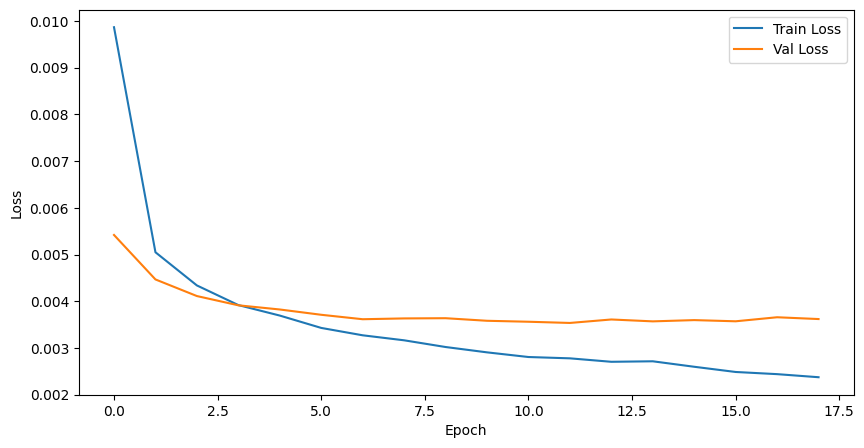

In [128]:
plt.figure(figsize=(10,5))
plt.plot(log['train_losses'], label='Train Loss')
plt.plot(log['test_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [129]:
classes = trainset.classes
classes

['Baked Potato',
 'Crispy Chicken',
 'Donut',
 'Fries',
 'Hot Dog',
 'Sandwich',
 'Taco',
 'Taquito',
 'apple_pie',
 'cheesecake',
 'chicken_curry',
 'ice_cream',
 'omelette',
 'sushi']

## Matrice di confusione

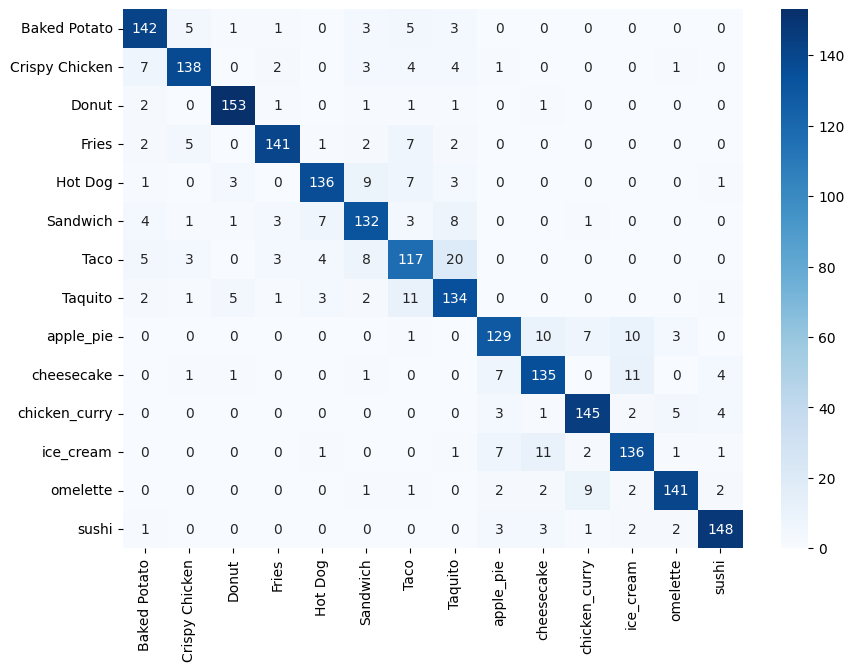

In [130]:
# print confusion matrix
if do_train:
  plot_confusion_matrix(model, val_loader, device)

## Set test

In [133]:
_, test_accuracy = test_epoch(model, test_loader, criterion, device)
print("Accuracy on test set: ", test_accuracy)

Accuracy on test set:  0.8571428571428571


## Conclusioni

# 📊 Relazione Finale: Classificazione di Immagini nel Settore Food

## Obiettivo del Progetto
Il progetto ha richiesto lo sviluppo e l'ottimizzazione di un modello avanzato di **Deep Learning** per la classificazione automatica di immagini appartenenti al settore alimentare (*Food Classification*).

L'attenzione si è concentrata in modo particolare sull'implementazione strategica di:
* **Transfer Learning:** Sfruttamento di backbone pre-addestrate per massimizzare l'estrazione delle feature.
* **Data Augmentation:** Configurazione di trasformazioni visive per incrementare la variabilità dei dati e prevenire l'overfitting.
* **Tecniche di Regolarizzazione e Tuning:** Ottimizzazione fine degli iperparametri per garantire elevate capacità di generalizzazione.

---

##  Sperimentazione e Confronto Architetturale

### 1. Baseline: MobileNetV3 (Small)
La rete **MobileNetV3_S** è stata selezionata come *baseline* iniziale del progetto. Questa prima fase è servita per testare la pipeline di caricamento, validare le trasformazioni di *Data Augmentation* e definire l'ambiente di training.

* **Risultati:** Nonostante la struttura estremamente leggera, la rete si è comportata egregiamente, raggiungendo un'**Accuracy sfiorata dell'83%**.

---

### 2. Architettura Principale: EfficientNetV2
Per superare il limite della baseline, si è passati all'implementazione di **EfficientNetV2**, un'architettura significativamente più profonda e robusta, in grado di gestire oltre **21 milioni di parametri**.

* **Accuracy in Validazione (Val Set):** $> 86\%$
* **Accuracy in Test (Test Set):** $> 85\%$

---

##  Ottimizzazione degli Iperparametri e Regolarizzazione

Durante lo sviluppo sono state sperimentate e confrontate diverse configurazioni operative per bilanciare la convergenza della rete ed evitare fenomeni di *overfitting*:

* **Data Augmentation:** Testate varie pipeline di trasformazione (rotazioni, flip, regolazione di luminosità/contrasto e ritagli) per arricchire il dataset.
* **Iperparametri dell'Ottimizzatore:** Fine-tuning mirato del *Learning Rate* (LR) e del *Weight Decay* per stabilizzare l'aggiornamento dei pesi.
* **Gestione delle Risorse:** Bilanciamento di *Batch Size* e *num_workers* per ottimizzare l'uso della GPU (T4) e saturate la memoria della scheda in modo efficiente.

---

##  Conclusioni
Il percorso svolto — dalla definizione della baseline con MobileNetV3 fino al raffinamento con EfficientNetV2 — ha consentito di raggiungere un eccellente livello di accuratezza e di generalizzazione, consolidando una solida comprensione pratica delle dinamiche di addestramento delle Reti Neurali e delle metodologie avanzate di Deep Learning.